# Parte 1 · Exploración y preparación del dataset

**Dataset:** iNaturalist 2021 Mini — 500 000 imágenes de entrenamiento, 10 000 especies, 50 por especie; 100 000 de validación (10 por especie).

Este notebook cubre la **Parte 1** del enunciado:

1. Números globales y dimensiones de las imágenes
2. Distribución y características taxonómicas
3. Ejemplos visuales, variabilidad intra-especie y similitud entre especies
4. Por qué el problema es difícil para Deep Learning
5. Pipeline de datos (carga → anotaciones → transformaciones → DataLoaders → reproducibilidad)
6. Construcción del escenario long-tail (Parte 7)

Requisitos previos: `python descargar_datos.py` y `sbatch preparar.sbatch` (ver README). No necesita GPU.

**Lo que pide el enunciado (§5) y dónde está:**

| Pide | Sección |
|---|---|
| nº de imágenes, nº de especies | §1 |
| dimensiones de las imágenes | §2 |
| distribución por grupo taxonómico, características taxonómicas | §3 |
| ejemplos visuales, variabilidad intra-especie, similitud entre especies | §4 |
| dificultades para el aprendizaje, por qué es difícil para DL | §5 |
| pipeline: cargar, anotaciones, asociar clase, transformaciones, DataLoaders | §6 (código en `preparar_datos.py`, `datos.py`) |
| reproducibilidad | §8 |
| construcción del escenario long-tail (Parte 7) | §7 |

In [1]:
import json, os, sys
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from config import DATA_ROOT, CACHE, RES_ALMACEN, SEMILLA
import datos

rng = np.random.default_rng(SEMILLA)          # toda selección "aleatoria" es reproducible
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

tr = datos.indice("train_mini")   # una fila por imagen: ruta, etiqueta, taxonomía, ancho, alto
va = datos.indice("val")
tr.head(3)

,id,file_name,width,height,etiqueta,especie,common_name,kingdom,phylum,class,order,family,genus,supercategory
0,2204200,train_mini/00000_Animalia_Annelida_Clitellata_...,375,500,0,Lumbricus terrestris,Common Earthworm,Animalia,Annelida,Clitellata,Haplotaxida,Lumbricidae,Lumbricus,Animalia
1,1884664,train_mini/00000_Animalia_Annelida_Clitellata_...,500,333,0,Lumbricus terrestris,Common Earthworm,Animalia,Annelida,Clitellata,Haplotaxida,Lumbricidae,Lumbricus,Animalia
2,826804,train_mini/00000_Animalia_Annelida_Clitellata_...,500,375,0,Lumbricus terrestris,Common Earthworm,Animalia,Annelida,Clitellata,Haplotaxida,Lumbricidae,Lumbricus,Animalia


## 1. Números globales

Las anotaciones siguen el formato COCO: tres listas (`images`, `annotations`, `categories`) enlazadas por id.
`preparar_datos.construir_indice` las une en una sola tabla. **La fila *i* de la tabla es la imagen *i* del array
preprocesado**, así la asociación imagen ↔ clase no depende del orden de lectura de ficheros.

In [2]:
resumen = pd.DataFrame({
    "imágenes": [len(tr), len(va)],
    "especies": [tr.etiqueta.nunique(), va.etiqueta.nunique()],
    "img/especie (mín)": [tr.etiqueta.value_counts().min(), va.etiqueta.value_counts().min()],
    "img/especie (máx)": [tr.etiqueta.value_counts().max(), va.etiqueta.value_counts().max()],
}, index=["train_mini", "val"])
niveles = ["kingdom", "phylum", "class", "order", "family", "genus"]
print("Taxones distintos por nivel:", {n: tr[n].nunique() for n in niveles})
resumen

Taxones distintos por nivel: {'kingdom': 3, 'phylum': 13, 'class': 51, 'order': 273, 'family': 1103, 'genus': 4884}


,imágenes,especies,img/especie (mín),img/especie (máx)
train_mini,500000,10000,50,50
val,100000,10000,10,10


## 2. Dimensiones de las imágenes

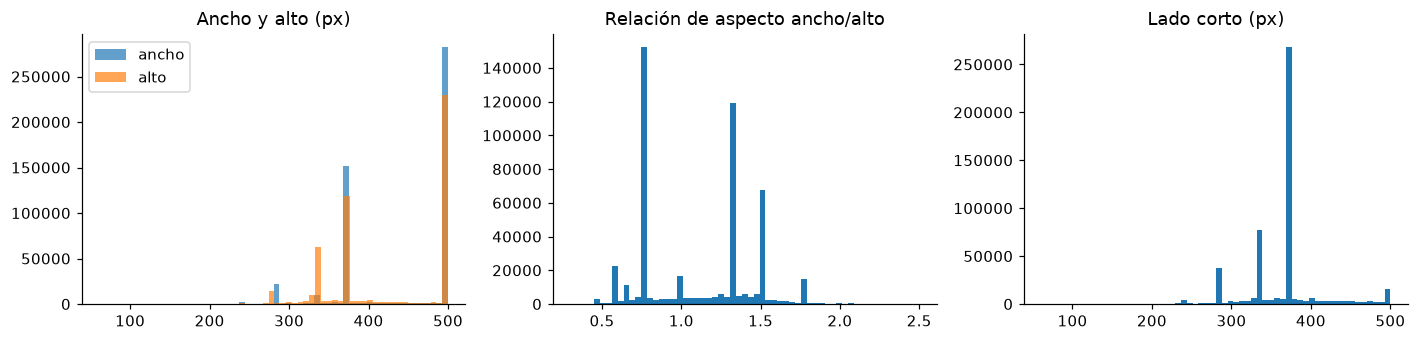

lado largo máximo: 500 px
aspecto 4:3 o 3:4 (±5%): 58.2%
cuadradas (±5%): 4.4%


In [3]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.2))
ax[0].hist(tr.width, bins=60, alpha=.7, label="ancho"); ax[0].hist(tr.height, bins=60, alpha=.7, label="alto")
ax[0].set_title("Ancho y alto (px)"); ax[0].legend()
asp = tr.width / tr.height
ax[1].hist(asp, bins=np.linspace(.3, 2.5, 60)); ax[1].set_title("Relación de aspecto ancho/alto")
lado_corto = np.minimum(tr.width, tr.height)
ax[2].hist(lado_corto, bins=60); ax[2].set_title("Lado corto (px)")
plt.tight_layout(); plt.show()
print(f"lado largo máximo: {max(tr.width.max(), tr.height.max())} px")
print(f"aspecto 4:3 o 3:4 (±5%): {((abs(asp-4/3)<.07)|(abs(asp-3/4)<.05)).mean():.1%}")
print(f"cuadradas (±5%): {(abs(asp-1)<.05).mean():.1%}")

**Lectura.** El lado largo está normalizado a ~500 px y la mayoría son fotos 4:3 de cámara o móvil. Al
redimensionar el lado corto a 144 px y recortar el centro se pierden los bordes laterales (~25 % del área en
una foto 4:3). En fotos de naturalistas el organismo suele estar centrado, pero no siempre: es una de las
limitaciones asumidas a cambio de poder entrenar 500k imágenes muchas veces (ver §5).

## 3. Distribución y características taxonómicas

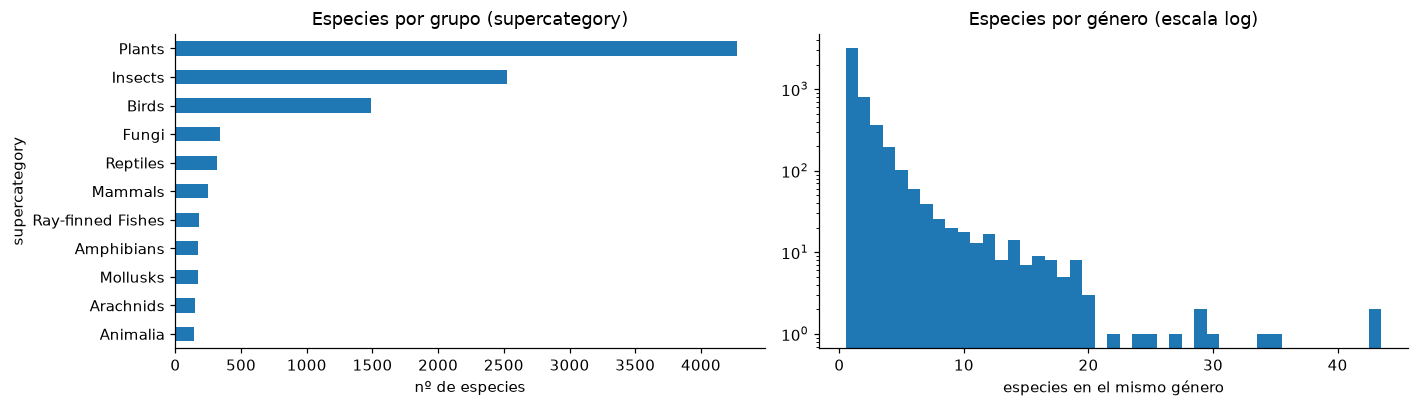

géneros con >1 especie: 1726 (35%)
especies que comparten género con otra: 6842 de 10 000
géneros con más especies: {'Carex': 43, 'Quercus': 43, 'Euphorbia': 35, 'Viola': 34, 'Papilio': 30}


supercategory,Plants,Insects,Birds,Fungi,Reptiles,Mammals,Ray-finned Fishes,Amphibians,Mollusks,Arachnids,Animalia
fracción de especies,0.427,0.253,0.149,0.034,0.031,0.025,0.018,0.017,0.017,0.015,0.014


In [4]:
esp = tr.drop_duplicates("etiqueta")          # una fila por especie
fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
esp.supercategory.value_counts().plot.barh(ax=ax[0]); ax[0].invert_yaxis()
ax[0].set_title("Especies por grupo (supercategory)"); ax[0].set_xlabel("nº de especies")
por_genero = esp.groupby("genus").size()
ax[1].hist(por_genero, bins=np.arange(1, por_genero.max() + 2) - .5, log=True)
ax[1].set_title("Especies por género (escala log)"); ax[1].set_xlabel("especies en el mismo género")
plt.tight_layout(); plt.show()

print(f"géneros con >1 especie: {(por_genero > 1).sum()} ({(por_genero > 1).mean():.0%})")
print(f"especies que comparten género con otra: {por_genero[por_genero > 1].sum()} de 10 000")
print("géneros con más especies:", por_genero.nlargest(5).to_dict())
esp.supercategory.value_counts(normalize=True).round(3).to_frame("fracción de especies").T

**Lectura.** A nivel de *especie* el dataset está perfectamente balanceado (50 imágenes cada una), pero a nivel
de *grupo* no: las plantas son ~43 % de las clases y los insectos ~25 %, mientras que anfibios o arácnidos
son <2 %. Un modelo que reparte capacidad por frecuencia de gradiente verá muchos más ejemplos de plantas.

La clave de *fine-grained*: miles de especies comparten género con otras. Distinguir dos especies del mismo
género (p. ej. dos *Carex* o dos *Quercus*) exige detalles finos (nervadura, textura, un color concreto) que a
128 px pueden no ser visibles.

## 4. Ejemplos visuales

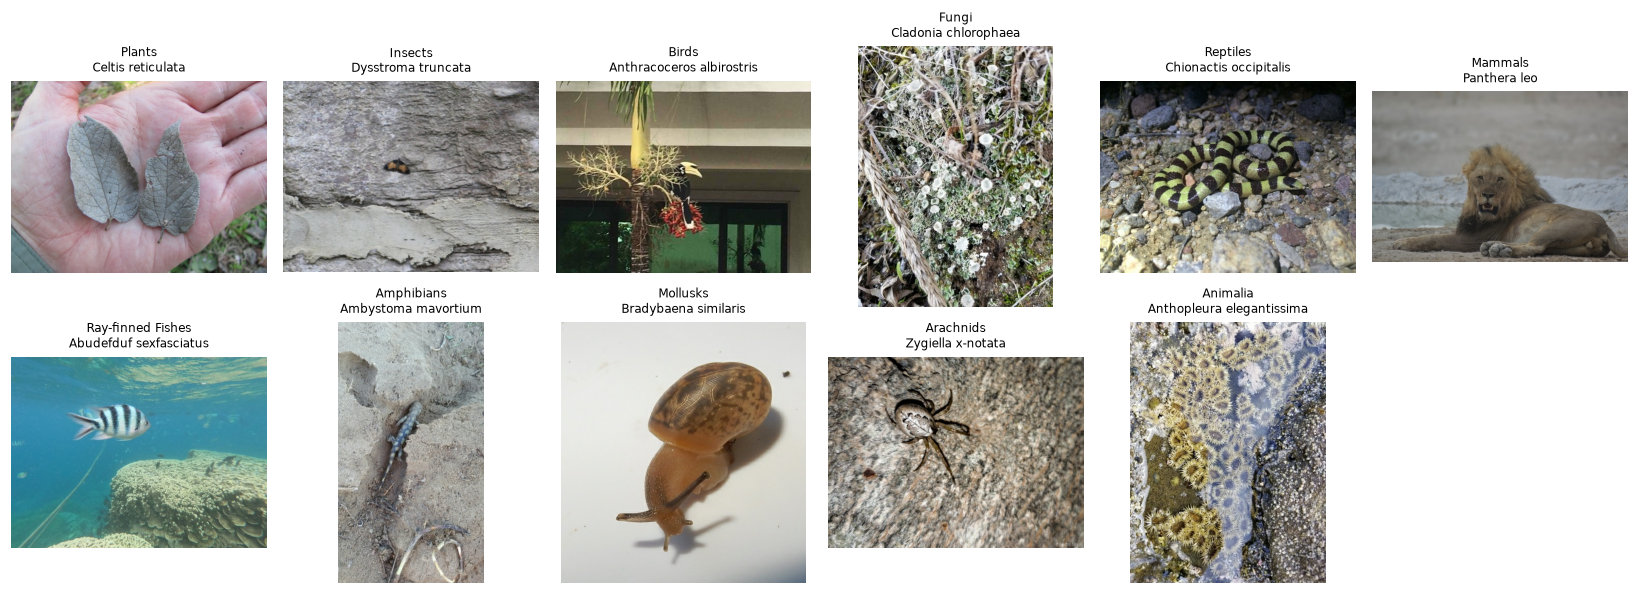

In [5]:
def ver(fila, ax, titulo=None):
    ax.imshow(Image.open(DATA_ROOT / fila.file_name).convert("RGB")); ax.axis("off")
    ax.set_title(titulo if titulo is not None else fila.especie, fontsize=8)

grupos = tr.supercategory.value_counts().index
fig, axs = plt.subplots(2, 6, figsize=(15, 5.5))
for ax, g in zip(axs.flat, grupos):
    f = tr[tr.supercategory == g].sample(1, random_state=SEMILLA).iloc[0]
    ver(f, ax, f"{g}\n{f.especie}")
for ax in axs.flat[len(grupos):]: ax.axis("off")
plt.tight_layout(); plt.show()

### Variabilidad visual dentro de una misma especie

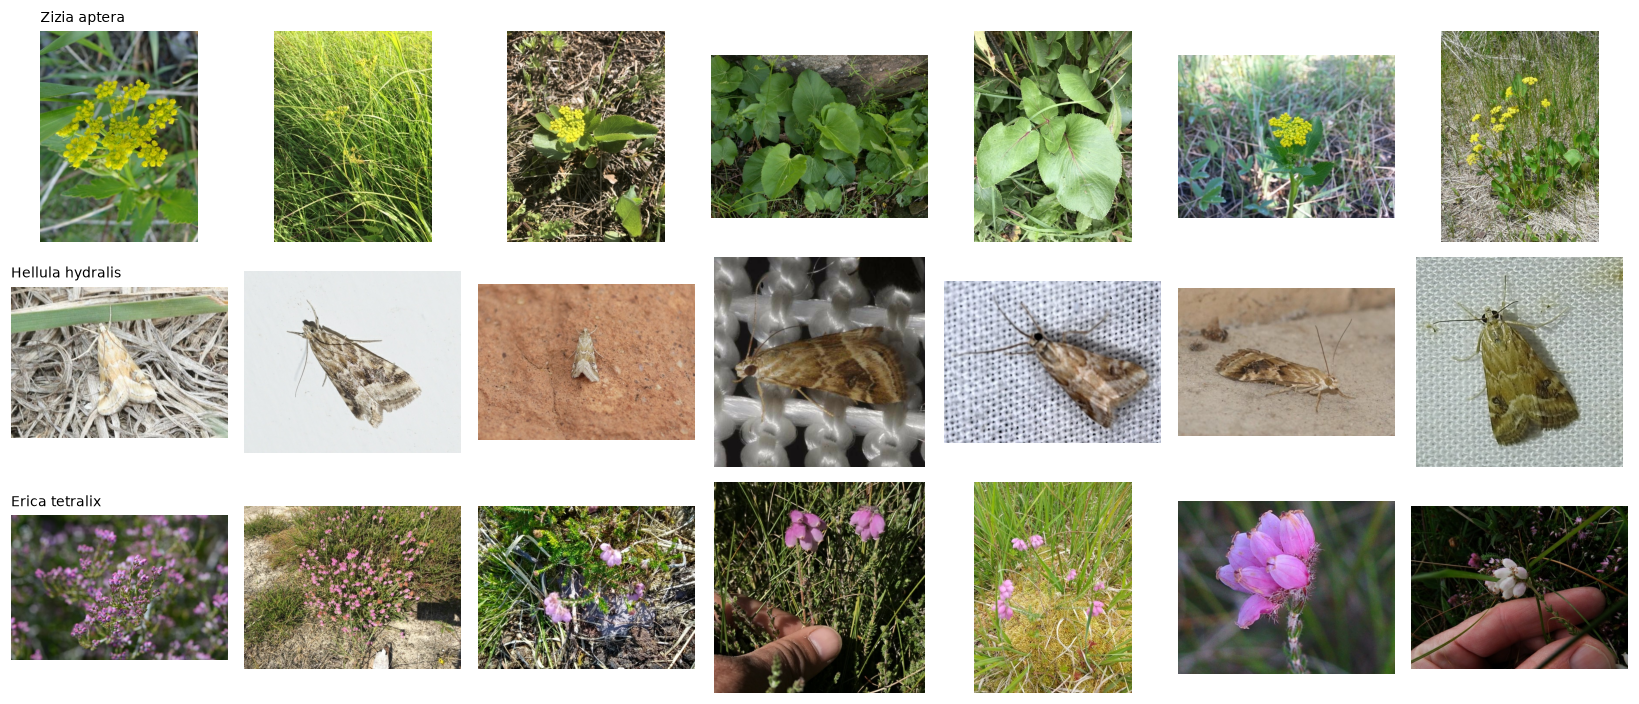

In [6]:
# Tres especies al azar, 7 imágenes de cada una
especies = rng.choice(tr.etiqueta.unique(), 3, replace=False)
fig, axs = plt.subplots(3, 7, figsize=(15, 6.5))
for fila_ax, e in zip(axs, especies):
    for ax, (_, f) in zip(fila_ax, tr[tr.etiqueta == e].sample(7, random_state=SEMILLA).iterrows()):
        ver(f, ax, "")
    fila_ax[0].set_title(tr[tr.etiqueta == e].especie.iloc[0], fontsize=9, loc="left")
plt.tight_layout(); plt.show()

Dentro de una especie cambian **la escala** (planta entera vs. primer plano de una flor), **la pose**, **el
estadio de vida** (oruga/adulto, flor/fruto, macho/hembra), **el fondo**, **la iluminación** y a veces sólo
aparece un rastro (hojas, una concha, una huella). La red debe ser invariante a todo eso con sólo 50 ejemplos.

### Similitud visual entre especies distintas (mismo género)

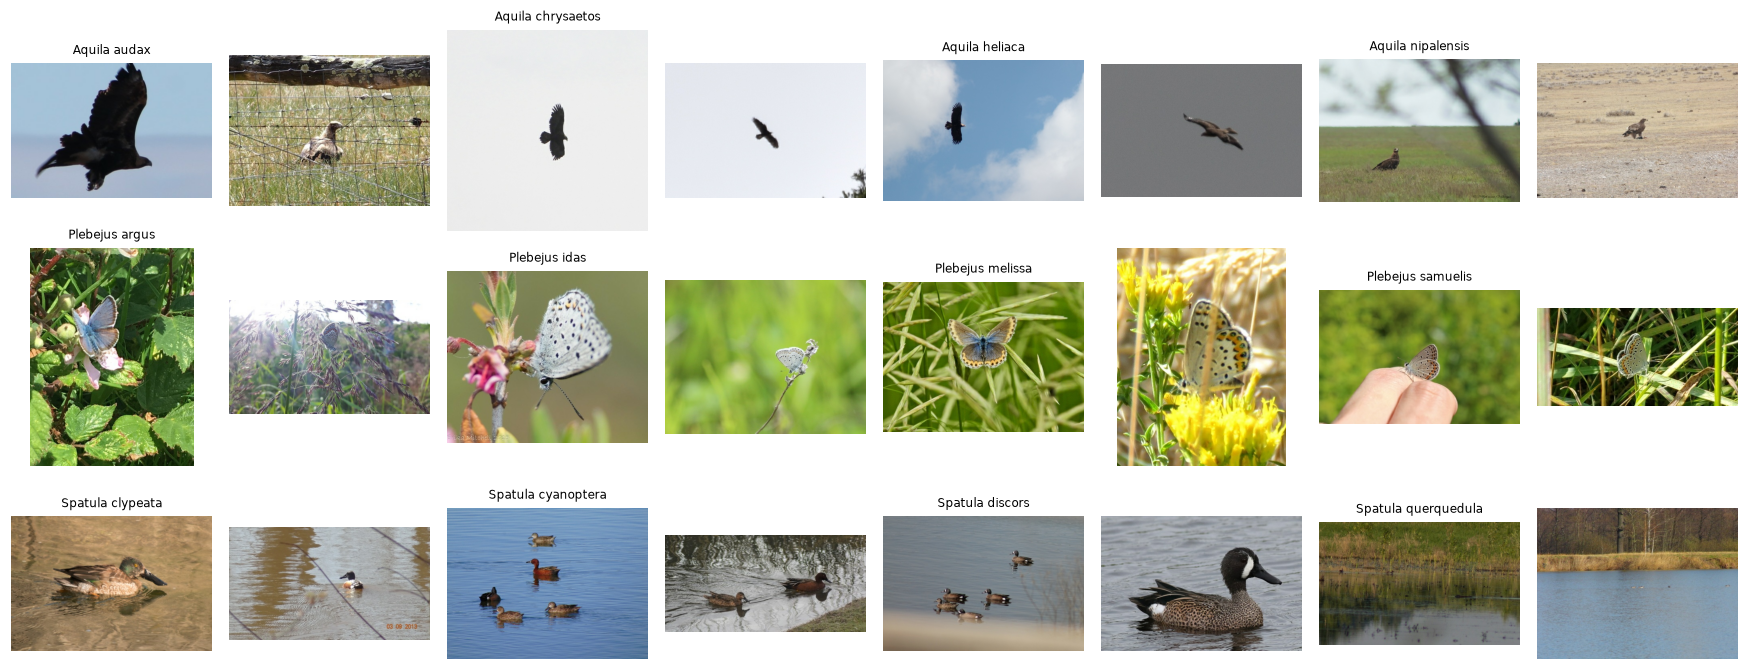

In [7]:
# Géneros con >=4 especies: mostramos 4 especies de 3 géneros, 2 imágenes cada una
cand = por_genero[por_genero >= 4].index
generos = rng.choice(cand, 3, replace=False)
fig, axs = plt.subplots(3, 8, figsize=(16, 6.5))
for fila_ax, g in zip(axs, generos):
    es = esp[esp.genus == g].etiqueta.to_numpy()[:4]
    k = 0
    for e in es:
        for _, f in tr[tr.etiqueta == e].sample(2, random_state=SEMILLA).iterrows():
            ver(f, fila_ax[k], f.especie if k % 2 == 0 else ""); k += 1
plt.tight_layout(); plt.show()

## 5. ¿Por qué es difícil para Deep Learning?

| Dificultad | Consecuencia para el modelo |
|---|---|
| **10 000 clases, 50 imágenes cada una** | Pocos ejemplos por clase ⇒ sobreajuste fácil. La capa final tiene $d \times 10^4$ pesos (20 M en ResNet-50). Accuracy al azar = 0,01 %. |
| **Fine-grained**: miles de especies congenéricas | La señal discriminativa está en detalles pequeños; la variación *entre* especies puede ser menor que la variación *dentro* de una especie. |
| **Alta variabilidad intra-clase** (escala, pose, estadio, sexo) | Hace falta invariancia fuerte; con 50 ejemplos no se cubren todos los modos. |
| **Fondos complejos, organismo pequeño** | Fotos "in the wild": el organismo puede ocupar <5 % de la imagen; el fondo (hábitat) correlaciona con la especie y puede inducir atajos. |
| **Resolución** | Reducir a 128 px (por coste) borra texturas y detalles finos. |
| **Desbalance entre grupos taxonómicos** | 43 % de las clases son plantas: la representación se sesga hacia ellas. |
| **Ruido de etiqueta** | Identificaciones de ciencia ciudadana (grado "research" pero no perfectas). |
| **Escala del cómputo** | 500k imágenes por época obligan a un pipeline eficiente (siguiente sección). |

La jerarquía taxonómica es a la vez una dificultad y una ayuda: los errores "razonables" (mismo género) son
distintos de los absurdos (otro reino), y así lo analizamos en `p8_evaluacion_errores.ipynb`.

## 6. Pipeline de datos

```
JPEG (~500 px)  ──preparar_datos.py (1 vez, 32 CPU)──►  memmap uint8 (N,144,144,3)  [31 GB train, 6 GB val]
                                                            │  DataLoader: cada worker lee un LOTE entero
                                                            ▼
                                                  uint8 pinned ──► GPU ──► AumentoGPU ──► red (B,3,128,128)
```

* **Cargar imágenes / leer anotaciones / asociar clase:** `preparar_datos.py` une el JSON en una tabla
  ordenada por (etiqueta, fichero) y escribe la imagen *i* en la posición *i* del memmap.
* **Transformaciones:** redimensionado único (lado corto → 144, recorte central) y, en cada lote,
  data augmentation **en GPU** (`datos.AumentoGPU`): recorte aleatorio 128, flip, color, borrado.
  Evaluación: recorte central 128 (misma proporción 0,89 que el clásico 224/256 de ImageNet).
* **DataLoaders:** `datos.cargador` — `BatchSampler` + dataset que devuelve lotes completos.
* **Reproducibilidad:** semillas fijas (Python, NumPy, PyTorch, CUDA), generador del sampler resembrado
  con `semilla + época`, subconjuntos long-tail construidos con `numpy.random.default_rng(42)`.

Por qué no un `ImageFolder` normal: decodificar un JPEG de 500 px cuesta ~5 ms de CPU; 500k por época
serían ~40 min-CPU por época, y la GPU (que procesa una ResNet-18 a 128 px a varios miles de img/s)
esperaría a los datos. Con el memmap la CPU sólo copia bytes.

/home/diego.pachecopedemonte/.venvs/dl/lib64/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


lote crudo: (8, 144, 144, 3) torch.uint8 | etiquetas: [1478, 1579, 3138, 3754, 6027, 6854, 7005, 7290]


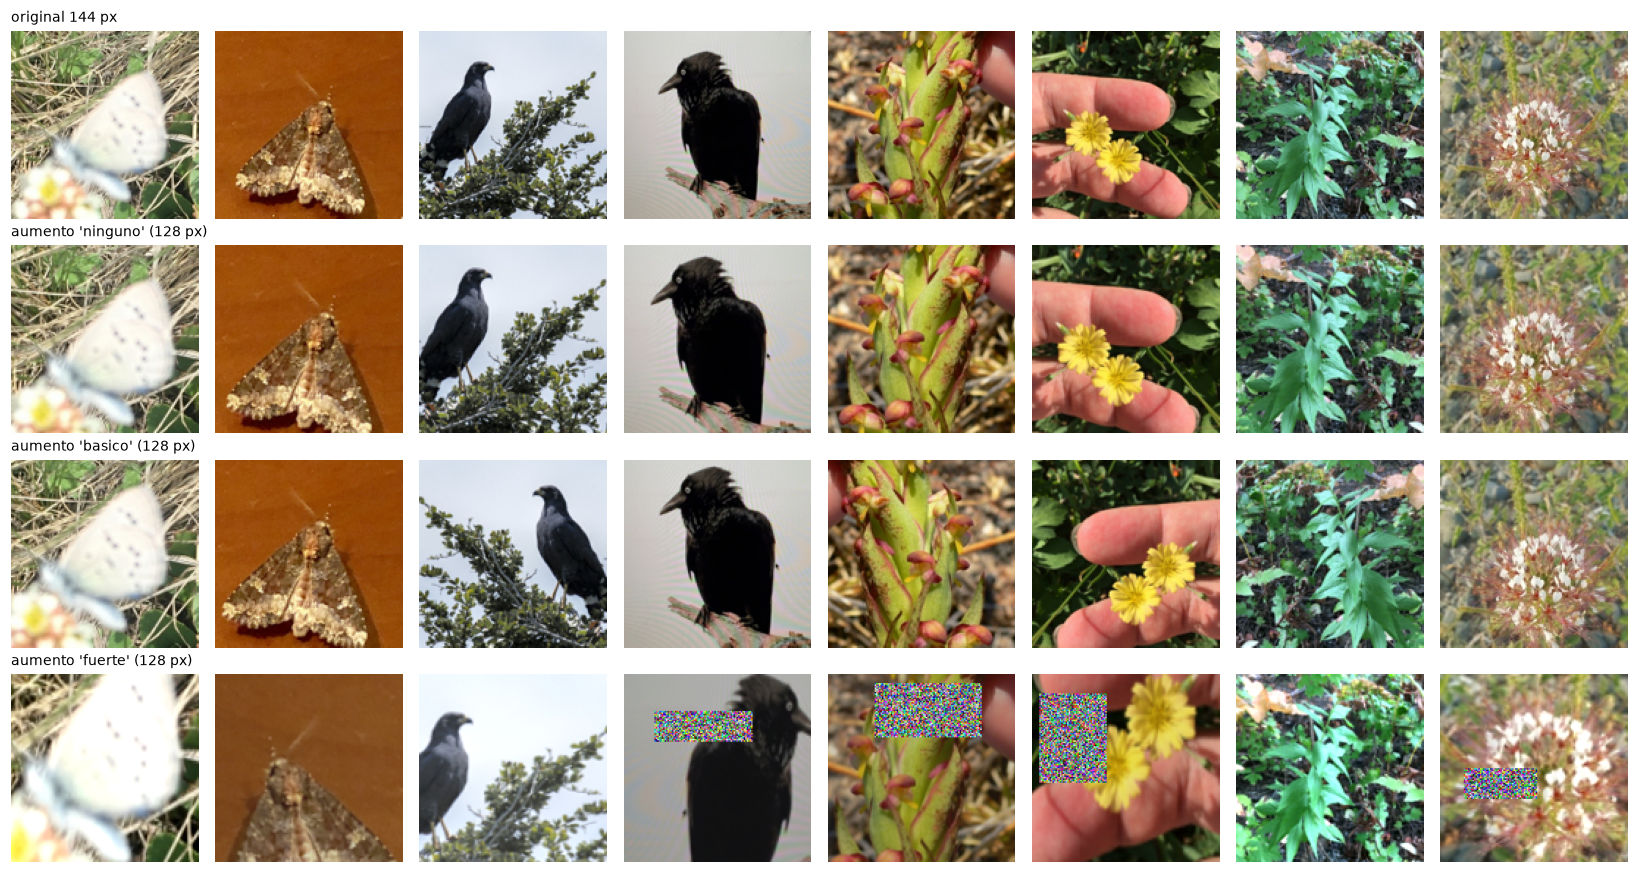

In [8]:
import torch
from datos import LotesMemmap, cargador, AumentoGPU

ds = LotesMemmap("val")
dl = cargador(ds, batch_size=8, entrenamiento=True, semilla=SEMILLA, workers=0)
xb, yb = next(iter(dl))
print("lote crudo:", tuple(xb.shape), xb.dtype, "| etiquetas:", yb[:8].tolist())

torch.manual_seed(SEMILLA)
niveles = ["ninguno", "basico", "fuerte"]
fig, axs = plt.subplots(len(niveles) + 1, 8, figsize=(15, 8))
for ax, im in zip(axs[0], xb): ax.imshow(im.numpy()); ax.axis("off")
axs[0, 0].set_title("original 144 px", loc="left", fontsize=9)
for fila, nivel in zip(axs[1:], niveles):
    x = AumentoGPU(nivel)(xb, entrenamiento=True)          # también funciona en CPU
    x = x * torch.tensor(datos.DESV).view(1, 3, 1, 1) + torch.tensor(datos.MEDIA).view(1, 3, 1, 1)
    for ax, im in zip(fila, x.clamp(0, 1).permute(0, 2, 3, 1)): ax.imshow(im.numpy()); ax.axis("off")
    fila[0].set_title(f"aumento '{nivel}' (128 px)", loc="left", fontsize=9)
plt.tight_layout(); plt.show()

**¿Puede el aumento destruir rasgos diagnósticos?** Sí, y por eso se eligió con cuidado:

* **Sin cambio de tono (hue)** ni conversión a gris: el color separa muchas especies (aves, setas, flores).
  El jitter de brillo/contraste/saturación es suave (±20 %).
* **Sin flip vertical ni rotaciones grandes:** las fotos tienen "arriba" (el cielo, el suelo, la dirección de
  crecimiento de una planta).
* **Flip horizontal sí:** la quiralidad casi nunca es diagnóstica... salvo en caracoles (la dirección de
  enrollamiento de la concha distingue especies). Es un caso donde el flip *miente*.
* **Random Resized Crop:** escala mínima 0,35 para no dejar fuera al organismo; aun así un recorte puede
  cortar justo el rasgo clave (p. ej. la cola de un ave).
* **Random Erasing** simula oclusiones (ramas, hojas) pero puede borrar la parte diagnóstica.

## 7. Escenario long-tail (Parte 7)

**Criterio** (`preparar_datos.construir_long_tail`, semilla 42): se baraja el orden de las 10 000 especies y la
de rango $r$ conserva
$$n(r) = \left\lfloor 50 \cdot (1/50)^{\,r/(C-1)} \right\rfloor,$$
un perfil exponencial de 50 a 1 imagen (factor de desbalance 50), como CIFAR-LT e ImageNet-LT. Barajar las
especies evita que el desbalance se alinee con la taxonomía (las etiquetas están ordenadas por reino). Qué
imágenes se conservan también se sortea.

**Grupos** (umbrales de ImageNet-LT escalados): frecuentes $n \ge 20$, intermedias $5 \le n < 20$,
minoritarias $n < 5$. La validación sigue siendo la oficial balanceada (10 por especie), así las métricas por
grupo son comparables.

**Control:** además se construye un subconjunto *balanceado con el mismo número total de imágenes*. Sin él,
"balanceado vs long-tail" mezclaría dos efectos: la forma de la distribución y la cantidad de datos.

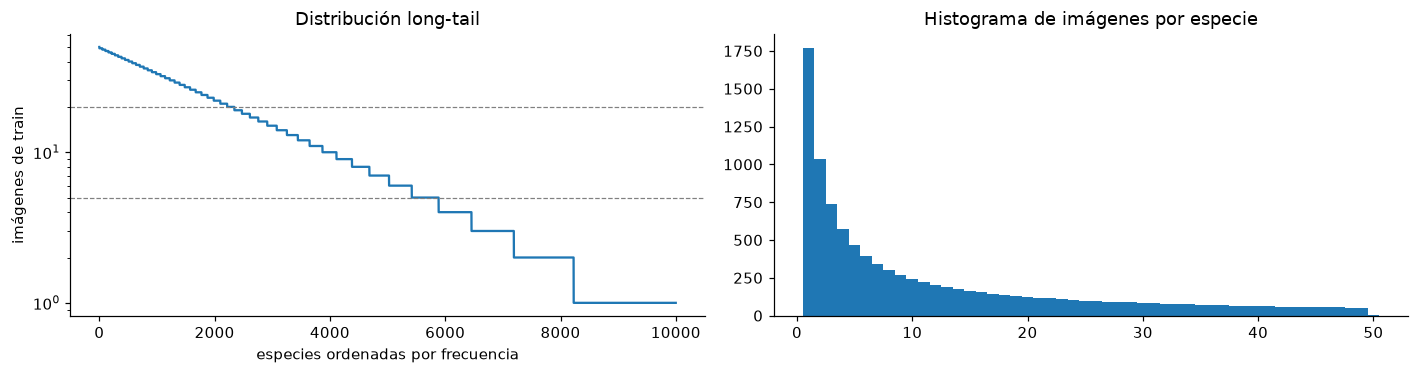

total long-tail: 120474 imágenes | control balanceado: 120000 (12 por especie)


,clases,imágenes,img/clase (rango),% imágenes
frecuentes,2343,75550,20–50,62.7
intermedias,3543,36593,5–19,30.4
minoritarias,4114,8331,1–4,6.9


In [9]:
lt = datos.long_tail()
n = lt["n_por_clase"]; g = lt["grupo"]
fig, ax = plt.subplots(1, 2, figsize=(13, 3.5))
orden = np.sort(n)[::-1]
ax[0].plot(orden); ax[0].set_yscale("log"); ax[0].set_xlabel("especies ordenadas por frecuencia")
ax[0].set_ylabel("imágenes de train"); ax[0].set_title("Distribución long-tail")
for u in (20, 5): ax[0].axhline(u, ls="--", c="gray", lw=.8)
ax[1].hist(n, bins=np.arange(0.5, 51.5)); ax[1].set_title("Histograma de imágenes por especie")
plt.tight_layout(); plt.show()

tabla = pd.DataFrame({
    "clases": [(g == k).sum() for k in range(3)],
    "imágenes": [n[g == k].sum() for k in range(3)],
    "img/clase (rango)": [f"{n[g == k].min()}–{n[g == k].max()}" for k in range(3)],
}, index=lt["nombres_grupo"])
tabla["% imágenes"] = (100 * tabla.imágenes / tabla.imágenes.sum()).round(1)
print(f"total long-tail: {len(lt['idx_lt'])} imágenes | control balanceado: {len(lt['idx_bal'])} "
      f"({len(lt['idx_bal']) // 10000} por especie)")
tabla

In [10]:
# ¿El desbalance quedó independiente de la taxonomía? (debería: se barajó el orden)
e = esp.set_index("etiqueta").loc[np.arange(10000)]
pd.crosstab(e.supercategory, pd.Series(lt["nombres_grupo"][g], index=e.index), normalize="index").round(2)

col_0,frecuentes,intermedias,minoritarias
supercategory,,,
Amphibians,0.26,0.35,0.39
Animalia,0.32,0.38,0.30
Arachnids,0.26,0.32,0.42
Birds,0.23,0.35,0.41
Fungi,0.21,0.35,0.43
Insects,0.23,0.36,0.41
Mammals,0.25,0.34,0.41
Mollusks,0.30,0.38,0.31
Plants,0.23,0.35,0.42


## 8. Reproducibilidad

* Toda la configuración de cada experimento está en `experimentos.py` y se guarda en `resultados/<ID>/config.json`.
* Semillas: `SEMILLA = 42` (`config.py`) para Python/NumPy/PyTorch/CUDA, el orden de los lotes (`semilla + época`)
  y la construcción del long-tail.
* `cudnn.benchmark` está activo por velocidad (no determinismo numérico mínimo). Para reproducibilidad
  bit a bit: `TORCH_DETERMINISTA=1`.
* Ninguna celda depende de estado oculto: este notebook sólo lee los ficheros producidos por
  `preparar_datos.py`.